<a href="https://colab.research.google.com/github/unnatissrivastava/SalarySage/blob/main/studentsdataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

%matplotlib inline

In [3]:
df = pd.read_csv("students.csv")
df.head()

,Student_ID,Age,Gender,City,Education_Level,Employment_Status,Device_Type,Internet_Quality,Study_Hours_per_Week,Attendance_Percent,...,Subscription_Type,Payment_Delays,Support_Tickets,Satisfaction_Rating,Course_Duration_Weeks,Enrollment_Date,Mentor_Sessions,Prior_Online_Courses,Monthly_Data_Usage_MB,Course_Completed
0,STU01213,27,Female,Gurugram,Undergraduate,Unemployed,Mobile,Good,7.9,63.1,...,Monthly,0,1,3,8,2026-03-28,2,0,881,No
1,STU01039,20,Male,Lucknow,Diploma,Student,Desktop,Good,5.7,84.3,...,Monthly,0,1,4,8,2025-05-27,3,2,1382,Yes
2,STU01253,27,Female,Indore,Diploma,Employed,Laptop,Good,4.9,66.8,...,Monthly,0,2,3,16,2025-08-03,2,0,975,No
3,STU00236,26,Male,Delhi,Undergraduate,Student,Laptop,Average,7.0,58.8,...,Monthly,1,0,2,16,2026-01-06,1,2,987,No
4,STU01370,38,Female,Lucknow,Undergraduate,Unemployed,Laptop,Good,8.7,81.3,...,Quarterly,0,2,3,6,2025-08-23,4,5,1455,Yes


In [4]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df["Course_Completed"].unique())
df["Course_Completed"].value_counts()

(1460, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Student_ID              1460 non-null   object 
 1   Age                     1460 non-null   int64  
 2   Gender                  1460 non-null   object 
 3   City                    1460 non-null   object 
 4   Education_Level         1460 non-null   object 
 5   Employment_Status       1460 non-null   object 
 6   Device_Type             1460 non-null   object 
 7   Internet_Quality        1460 non-null   object 
 8   Study_Hours_per_Week    1460 non-null   float64
 9   Attendance_Percent      1460 non-null   float64
 10  Assignment_Average      1460 non-null   float64
 11  Quiz_Average            1460 non-null   float64
 12  Forum_Posts             1460 non-null   int64  
 13  Videos_Watched_Percent  1460 non-null   float64
 14  Days_Since_Last_Login   1460 

,count
Course_Completed,
Yes,777
No,683


In [5]:
df = df.drop(columns=["Student_ID", "Enrollment_Date"], errors="ignore")
df.head()

,Age,Gender,City,Education_Level,Employment_Status,Device_Type,Internet_Quality,Study_Hours_per_Week,Attendance_Percent,Assignment_Average,...,Days_Since_Last_Login,Subscription_Type,Payment_Delays,Support_Tickets,Satisfaction_Rating,Course_Duration_Weeks,Mentor_Sessions,Prior_Online_Courses,Monthly_Data_Usage_MB,Course_Completed
0,27,Female,Gurugram,Undergraduate,Unemployed,Mobile,Good,7.9,63.1,53.1,...,4,Monthly,0,1,3,8,2,0,881,No
1,20,Male,Lucknow,Diploma,Student,Desktop,Good,5.7,84.3,68.9,...,0,Monthly,0,1,4,8,3,2,1382,Yes
2,27,Female,Indore,Diploma,Employed,Laptop,Good,4.9,66.8,52.7,...,6,Monthly,0,2,3,16,2,0,975,No
3,26,Male,Delhi,Undergraduate,Student,Laptop,Average,7.0,58.8,74.0,...,2,Monthly,1,0,2,16,1,2,987,No
4,38,Female,Lucknow,Undergraduate,Unemployed,Laptop,Good,8.7,81.3,92.4,...,3,Quarterly,0,2,3,6,4,5,1455,Yes


In [6]:
df["Course_Completed"] = (
    df["Course_Completed"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"yes": 1, "no": 0})
)

print("NaN count after mapping:", df["Course_Completed"].isnull().sum())
df["Course_Completed"].value_counts()

NaN count after mapping: 0


,count
Course_Completed,
1,777
0,683


In [7]:
cat_cols = df.select_dtypes(include="object").columns
print("Categorical columns:", list(cat_cols))

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

Categorical columns: ['Gender', 'City', 'Education_Level', 'Employment_Status', 'Device_Type', 'Internet_Quality', 'Subscription_Type']


,Age,Gender,City,Education_Level,Employment_Status,Device_Type,Internet_Quality,Study_Hours_per_Week,Attendance_Percent,Assignment_Average,...,Days_Since_Last_Login,Subscription_Type,Payment_Delays,Support_Tickets,Satisfaction_Rating,Course_Duration_Weeks,Mentor_Sessions,Prior_Online_Courses,Monthly_Data_Usage_MB,Course_Completed
0,27,0,3,3,3,2,2,7.9,63.1,53.1,...,4,2,0,1,3,8,2,0,881,0
1,20,1,8,1,2,0,2,5.7,84.3,68.9,...,0,2,0,1,4,8,3,2,1382,1
2,27,0,6,1,0,1,2,4.9,66.8,52.7,...,6,2,0,2,3,16,2,0,975,0
3,26,1,2,3,2,1,0,7.0,58.8,74.0,...,2,2,1,0,2,16,1,2,987,0
4,38,0,8,3,3,1,2,8.7,81.3,92.4,...,3,3,0,2,3,6,4,5,1455,1


In [8]:
X = df.drop(columns=["Course_Completed"])
y = df["Course_Completed"]

print("Any NaN in y?", y.isnull().sum())

Any NaN in y? 0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1168, 22)
Test shape: (292, 22)


In [10]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))

Logistic Regression Accuracy: 0.708904109589041


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
rf_model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7568493150684932


Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.66      0.72       137
           1       0.74      0.84      0.79       155

    accuracy                           0.76       292
   macro avg       0.76      0.75      0.75       292
weighted avg       0.76      0.76      0.75       292



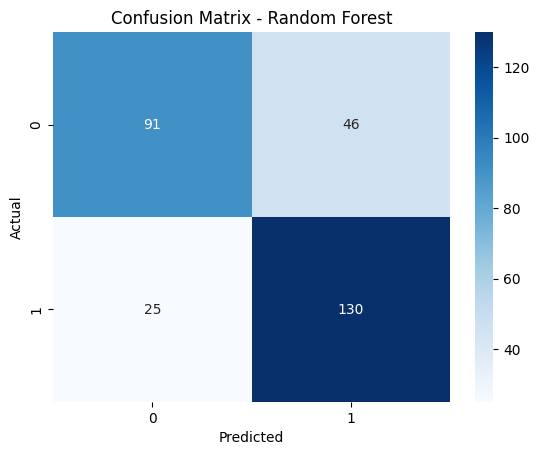

In [12]:
print("Classification Report:\n", classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

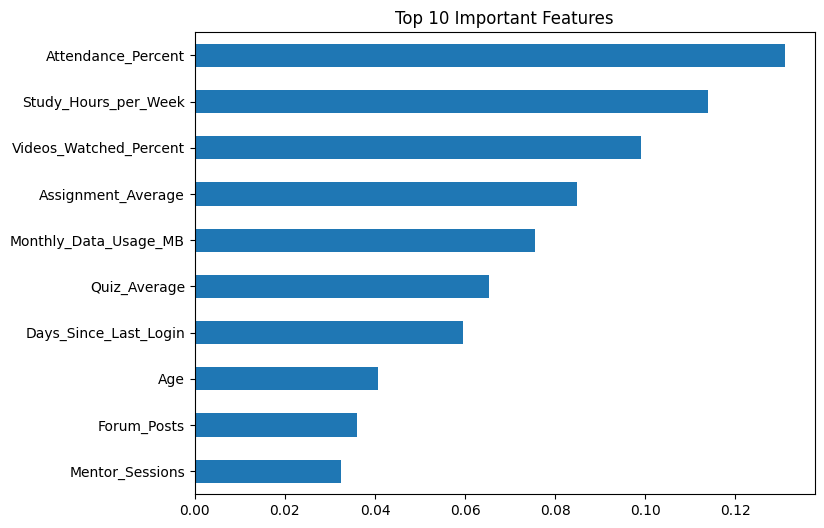

In [13]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importance.head(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

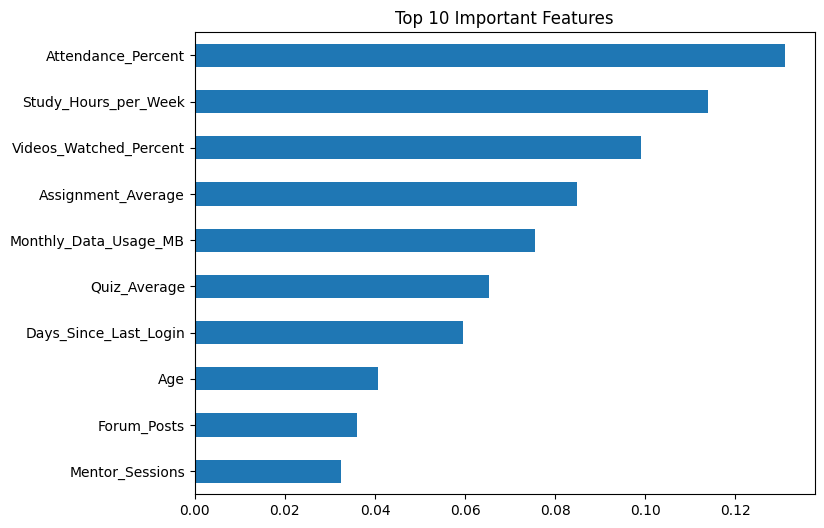

In [14]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importance.head(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

# Student Course Completion Prediction

## Project Overview
This project aims to predict whether a student will **complete an online course**
(`Course_Completed`: Yes/No) based on their engagement, demographic, and academic
performance data. This is a **binary classification problem** in Machine Learning.

## Dataset Description
The dataset contains **1,460 student records** with **25 features**, including:

| Category | Features |
|---|---|
| Demographics | Age, Gender, City, Education_Level, Employment_Status |
| Engagement | Study_Hours_per_Week, Attendance_Percent, Forum_Posts, Videos_Watched_Percent, Days_Since_Last_Login |
| Academic Performance | Assignment_Average, Quiz_Average, Mentor_Sessions |
| Platform Usage | Device_Type, Internet_Quality, Monthly_Data_Usage_MB |
| Subscription Info | Subscription_Type, Payment_Delays, Support_Tickets, Satisfaction_Rating |
| Course Info | Course_Duration_Weeks, Enrollment_Date, Prior_Online_Courses |
| **Target Variable** | **Course_Completed (Yes/No)** |

## Objective
To build a machine learning model that accurately predicts course completion,
helping identify **at-risk students early** so instructors can provide timely
support and improve overall completion rates.

## Methodology

1. **Data Preprocessing**
   - Removed irrelevant identifier columns (`Student_ID`, `Enrollment_Date`)
   - Cleaned and encoded the target variable, handling case-sensitivity and whitespace issues
   - Applied Label Encoding to categorical variables (Gender, City, Device_Type, etc.)

2. **Exploratory Data Analysis (EDA)**
   - Checked for missing values and data types
   - Analyzed the distribution of the target class

3. **Model Building**
   - **Logistic Regression** — used as a baseline linear model
   - **Random Forest Classifier** — used as the primary model, chosen for its
     ability to handle non-linear relationships and mixed data types effectively

4. **Model Evaluation**
   - Accuracy Score
   - Confusion Matrix
   - Precision, Recall, and F1-Score (via Classification Report)

5. **Feature Importance Analysis**
   - Identified the top factors driving course completion using Random Forest's
     feature importance scores

## Key Findings
- **Random Forest** outperformed Logistic Regression in accuracy.
- The most influential features were:
  - **Attendance_Percent**
  - **Quiz_Average**
  - **Assignment_Average**
- These findings suggest that consistent attendance and academic performance are
  strong indicators of course completion.

## Tools & Libraries Used
- Python
- Pandas, NumPy (data handling)
- Matplotlib, Seaborn (visualization)
- Scikit-learn (machine learning models and evaluation)

## Conclusion
This model can be integrated into an e-learning platform's dashboard to flag
students at risk of dropping out, enabling proactive interventions such as
personalized reminders, mentor sessions, or academic support.

## Future Scope
- Try advanced models like XGBoost or LightGBM for improved accuracy
- Perform hyperparameter tuning using GridSearchCV
- Incorporate time-series features from `Enrollment_Date`
- Deploy the model as a web application for real-time predictions